In [1]:
"""
Stationarity analysis for the PlasmoEpiGen simulations.
The script evaluates late-time stochastic stability and estimates the onset of the 
final stationary regime across stochastic replicates.
"""
from pathlib import Path
import re
import numpy as np
import pandas as pd

BLOCK_DAYS = 30.0
FINAL_REF_DAYS = 180.0
CONSECUTIVE_BLOCKS = 3
LATER_COMPATIBILITY = 0.90
ZERO_TOL = 1e-12

RESULTS_ROOT = Path("./results/Main_Simulations")
OUTPUT_ROOT = Path("./results/Stationarity")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

METRIC_COLUMNS = {"Prev": "Prev", "MOI": "MOI_Humans_mean", "PI": "PI_Humans", 
                  "SH": "SH_Humans", "ERR": "ratio_reco"}
METRIC_LABELS = {"Prev": "Human infection prevalence", "MOI": "Mean human MOI", 
                 "PI": "Human-stage parasite population genetic diversity", 
                 "SH": "Normalized Shannon diversity", "ERR": "Effective recombination ratio"}

error_message = ("was not found. Run this notebook from the repository test/ directory with " 
                 "outputs under test/results/Main_Simulations/.")

if not RESULTS_ROOT.exists():
    raise FileNotFoundError(f"{RESULTS_ROOT} {error_message}")

In [2]:
# Helper functions #

SCENARIO_RE = re.compile(r"IGD_(?P<pi0>[\d.]+)_BR_(?P<amax>[\d.]+)_NH_(?P<nh>\d+)_MxH_(?P<mxh>[\d.]+)")

# Parse scenario parameters from the folder name #
def parse_scenario_name(name):
    match = SCENARIO_RE.fullmatch(name)
    if match is None:
        return {"pi0_pct": np.nan, "amax": np.nan, "Nh": np.nan, "MxH": np.nan}
    out = match.groupdict()
    return {"pi0_pct": float(out["pi0"]), "amax": float(out["amax"]), "Nh": int(out["nh"]), 
            "MxH": float(out["mxh"])}

# Load and prepare all stochastic replicates for one scenario #
def load_replicates(folder):
    files = sorted(folder.glob("Iteration_proof_*.txt"))
    if not files:
        raise FileNotFoundError(f"No Iteration_proof_*.txt files found in {folder}")
    replicates, final_times = [], []
    required = {"time", "HS", "HM", "HPC", "MOI_Humans_mean", "PI_Humans", "SH_Humans", "ratio_reco"}
    for fn in files:
        df = pd.read_csv(fn, sep=";")
        missing = required.difference(df.columns)
        if missing:
            raise ValueError(f"{fn} is missing columns: {sorted(missing)}")
        df = df.sort_values("time").copy()
        total_h = df["HS"] + df["HM"] + df["HPC"]
        df["Prev"] = np.where(total_h > 0, (df["HM"] + df["HPC"]) / total_h, 0.0)
        replicates.append(df[["time"] + list(METRIC_COLUMNS.values())].copy())
        final_times.append(float(df["time"].iloc[-1]))
    unique_final = np.unique(final_times)
    if len(unique_final) != 1:
        raise ValueError(f"Replicates in {folder.name} do not share the same final time: {unique_final}")
    return replicates, float(unique_final[0])

# Calculate the interquartile range using linear quantile interpolation #
def iqr_linear(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan
    q25, q75 = np.quantile(values, [0.25, 0.75], method="linear")
    return float(q75 - q25)

# Calculate 30-day block medians and IQRs across stochastic replicates #
def compute_block_stats(replicates, final_day):
    nblocks, rows = int(final_day / BLOCK_DAYS), []
    for b in range(nblocks):
        start, end = b * BLOCK_DAYS, (b + 1) * BLOCK_DAYS
        row = {"start": start, "end": end}
        for metric, source_col in METRIC_COLUMNS.items():
            replicate_means = []
            for df in replicates:
                block = df[(df["time"] >= start) & (df["time"] < end)]
                if not block.empty:
                    replicate_means.append(float(block[source_col].mean()))
            row[f"{metric}_median"] = float(np.median(replicate_means)) if replicate_means else np.nan
            row[f"{metric}_iqr"] = iqr_linear(replicate_means) if replicate_means else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

# Select the final 180 days used to define the late-time reference regime #
def final_reference_blocks(block_stats, final_day):
    ref = block_stats[block_stats["end"] > final_day - FINAL_REF_DAYS].copy()
    if len(ref) != 6:
        print(f"[WARN] Expected 6 final reference blocks but found {len(ref)} for final_day={final_day}.")
    return ref

# Evaluate late-time stationarity by comparing temporal drift with stochastic variation #
def late_time_diagnostics(block_stats, final_day):
    ref, out = final_reference_blocks(block_stats, final_day), {}
    for metric in METRIC_COLUMNS:
        medians = ref[f"{metric}_median"].dropna().to_numpy(float)
        iqrs = ref[f"{metric}_iqr"].dropna().to_numpy(float)
        median_range = float(medians.max() - medians.min())
        typical_iqr = float(np.median(iqrs))
        if typical_iqr < ZERO_TOL and median_range < ZERO_TOL:
            drift_ratio, stable = 0.0, True
        elif typical_iqr < ZERO_TOL:
            drift_ratio, stable = np.inf, False
        else:
            drift_ratio = median_range / typical_iqr
            stable = drift_ratio <= 1.0
        out[metric] = {"temporal_drift": median_range, "typical_iqr": typical_iqr, 
                       "drift_ratio": drift_ratio, "stable": stable}
    return out

# Define the center and spread of the final stationary reference regime #
def final_regime_reference(block_stats, final_day):
    ref, reference = final_reference_blocks(block_stats, final_day), {}
    for metric in METRIC_COLUMNS:
        reference[metric] = {"center": float(np.median(ref[f"{metric}_median"].dropna())), 
                             "spread": float(np.median(ref[f"{metric}_iqr"].dropna()))}
    return reference

# Mark each temporal block as compatible or incompatible with the final regime #
def mark_compatible_blocks(block_stats, reference):
    out = block_stats.copy()
    for metric in METRIC_COLUMNS:
        center, spread, value = reference[metric]["center"], reference[metric]["spread"], out[f"{metric}_median"]
        out[f"{metric}_stable"] = (value - center).abs() < ZERO_TOL if spread < ZERO_TOL else (value - center).abs() <= spread
    out["ALL_stable"] = out[[f"{metric}_stable" for metric in METRIC_COLUMNS]].all(axis=1)
    return out

# Estimate the first sustained onset of metric-specific and joint stationarity #
def estimate_onset(block_stats):
    onset = {}
    for metric in list(METRIC_COLUMNS) + ["ALL"]:
        key, found = f"{metric}_stable", np.nan
        for i in range(len(block_stats) - CONSECUTIVE_BLOCKS + 1):
            if not block_stats.iloc[i:i + CONSECUTIVE_BLOCKS][key].all():
                continue
            later = block_stats.iloc[i:][key]
            if float(later.mean()) >= LATER_COMPATIBILITY:
                found = float(block_stats.iloc[i]["start"])
                break
        onset[metric] = found
    return onset

In [3]:
# Run all scenarios #

late_time_rows, onset_rows, temporal_rows = [], [], []
scenario_dirs = sorted([p for p in RESULTS_ROOT.glob("IGD_*") if p.is_dir()])

for folder in scenario_dirs:
    meta = parse_scenario_name(folder.name)
    replicates, final_day = load_replicates(folder)
    block_stats = compute_block_stats(replicates, final_day)

    late = late_time_diagnostics(block_stats, final_day)
    late_row = {"scenario": folder.name, **meta, "n_replicates": len(replicates), "final_day": final_day}
    for metric in METRIC_COLUMNS:
        late_row[f"{metric}_drift"] = late[metric]["temporal_drift"]
        late_row[f"{metric}_typical_IQR"] = late[metric]["typical_iqr"]
        late_row[f"{metric}_ratio"] = late[metric]["drift_ratio"]
        late_row[f"{metric}_stable"] = late[metric]["stable"]
    late_row["ALL_stable"] = all(late[m]["stable"] for m in METRIC_COLUMNS)
    late_time_rows.append(late_row)

    reference = final_regime_reference(block_stats, final_day)
    marked = mark_compatible_blocks(block_stats, reference)
    onset = estimate_onset(marked)
    onset_row = {"scenario": folder.name, **meta, "n_replicates": len(replicates), "final_day": final_day}
    for metric in METRIC_COLUMNS:
        onset_row[f"{metric}_onset_day"] = onset[metric]
        onset_row[f"{metric}_onset_year"] = onset[metric] / 365.0 if pd.notna(onset[metric]) else np.nan
    onset_row["Joint_onset_day"] = onset["ALL"]
    onset_row["Joint_onset_year"] = onset["ALL"] / 365.0 if pd.notna(onset["ALL"]) else np.nan
    onset_rows.append(onset_row)

    marked = marked.copy()
    marked.insert(0, "scenario", folder.name)
    for key, value in meta.items():
        marked[key] = value
    marked["year"] = marked["end"] / 365.0
    temporal_rows.append(marked)

late_time_df = pd.DataFrame(late_time_rows).sort_values(["pi0_pct", "amax"]).reset_index(drop=True)
onset_df = pd.DataFrame(onset_rows).sort_values(["pi0_pct", "amax"]).reset_index(drop=True)
temporal_df = pd.concat(temporal_rows, ignore_index=True) if temporal_rows else pd.DataFrame()

print(f"Scenarios analyzed: {len(late_time_df)}")
print(f"All late-time stationary: {int(late_time_df['ALL_stable'].sum())}/{len(late_time_df)}")
joint = onset_df["Joint_onset_year"].dropna()
if not joint.empty:
    print(f"Earliest joint onset: {joint.min():.2f} years")
    print(f"Median joint onset: {joint.median():.2f} years")
    print(f"Latest joint onset: {joint.max():.2f} years")

Scenarios analyzed: 55
All late-time stationary: 55/55
Earliest joint onset: 0.90 years
Median joint onset: 5.01 years
Latest joint onset: 6.82 years


In [4]:
# Supplementary table #
ratio_cols = [f"{m}_ratio" for m in METRIC_COLUMNS]
supp_table = late_time_df[["scenario", "pi0_pct", "amax"] + ratio_cols + ["ALL_stable"]].merge(onset_df[["scenario", "Joint_onset_year"]], on="scenario", how="left")
supp_table["Max_drift_IQR_ratio"] = supp_table[ratio_cols].max(axis=1)
supp_table = supp_table[["pi0_pct", "amax", "Prev_ratio", "MOI_ratio", "PI_ratio", "SH_ratio", "ERR_ratio", "Max_drift_IQR_ratio", "ALL_stable", "Joint_onset_year"]].sort_values(["pi0_pct", "amax"]).reset_index(drop=True)
supp_table = supp_table.rename(columns={"pi0_pct": "Initial diversity pi0 (%)", "amax": "a_max (bites/day)", "Prev_ratio": "Prevalence drift/IQR", "MOI_ratio": "MOI drift/IQR", "PI_ratio": "Human-stage parasite population genetic diversity drift/IQR", "SH_ratio": "Normalized Shannon diversity drift/IQR", "ERR_ratio": "ERR drift/IQR", "Max_drift_IQR_ratio": "Maximum drift/IQR", "ALL_stable": "All metrics stationary", "Joint_onset_year": "Joint stationarity onset (years)"})

late_time_df.to_csv(OUTPUT_ROOT / "late_time_stationarity_diagnostics.csv", index=False)
onset_df.to_csv(OUTPUT_ROOT / "stationarity_onset.csv", index=False)
temporal_df.to_csv(OUTPUT_ROOT / "temporal_stationarity.csv", index=False)
supp_table.to_csv(OUTPUT_ROOT / "Supplementary_Table_Stationarity.csv", index=False)

print("")
print("Saved:")
for fn in ["late_time_stationarity_diagnostics.csv", 
           "stationarity_onset.csv", "temporal_stationarity.csv", 
           "Supplementary_Table_Stationarity.csv"]:
    print(" -", OUTPUT_ROOT / fn)

supp_table.round(3)


Saved:
 - results/Stationarity/late_time_stationarity_diagnostics.csv
 - results/Stationarity/stationarity_onset.csv
 - results/Stationarity/temporal_stationarity.csv
 - results/Stationarity/Supplementary_Table_Stationarity.csv


,Initial diversity pi0 (%),a_max (bites/day),Prevalence drift/IQR,MOI drift/IQR,Human-stage parasite population genetic diversity drift/IQR,Normalized Shannon diversity drift/IQR,ERR drift/IQR,Maximum drift/IQR,All metrics stationary,Joint stationarity onset (years)
0,10.0,0.1,0.000,0.000,0.000,0.000,0.000,0.000,True,3.863
1,10.0,0.2,0.000,0.000,0.000,0.000,0.000,0.000,True,5.178
2,10.0,0.3,0.238,0.000,0.000,0.000,0.000,0.238,True,5.507
3,10.0,0.4,0.238,0.435,0.152,0.168,0.000,0.435,True,3.616
4,10.0,0.6,0.115,0.100,0.156,0.146,0.000,0.156,True,0.986
5,10.0,0.8,0.191,0.063,0.000,0.214,0.000,0.214,True,0.986
6,10.0,1.0,0.158,0.194,0.000,0.154,0.000,0.194,True,2.466
7,10.0,1.5,0.415,0.228,0.000,0.129,0.000,0.415,True,5.836
8,10.0,2.0,0.530,0.100,0.000,0.050,0.000,0.530,True,5.425
9,10.0,2.5,0.192,0.162,0.000,0.127,0.000,0.192,True,6.164


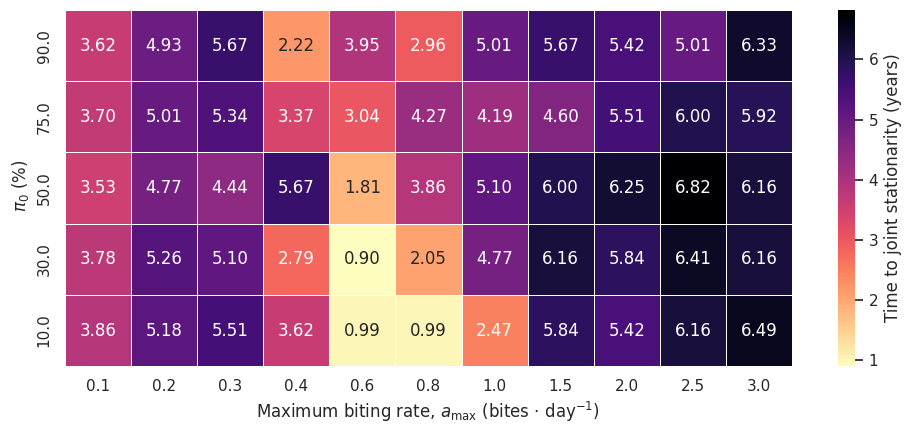

In [31]:
# Joint stationarity onset heatmap #

heatmap_data = supp_table.pivot( index="Initial diversity pi0 (%)",
                                columns="a_max (bites/day)",
                                values="Joint stationarity onset (years)")

heatmap_data = heatmap_data.sort_index(ascending=False)

plt.figure(figsize=(10, 4.5))

sns.heatmap( heatmap_data,
            annot=True,fmt=".2f",
            cmap="magma_r",linewidths=0.5,
            cbar_kws={"label": "Time to joint stationarity (years)"})

plt.xlabel(r"Maximum biting rate, $a_{\max}$ (bites $\cdot$ day$^{-1}$)")
plt.ylabel(r" $\pi_0$ (%)")

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "Figure_S2_stationarity_onset_heatmap.png", bbox_inches="tight",dpi=600)
plt.show()